<a href="https://colab.research.google.com/github/MarinaVoit/python_for_ds_tasks/blob/main/Maryna_Voit_HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [40]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1,4,Saturday,5,52,2011,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12,19,Wednesday,2,51,2012,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12,20,Wednesday,2,51,2012,19
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12,21,Wednesday,2,51,2012,19


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

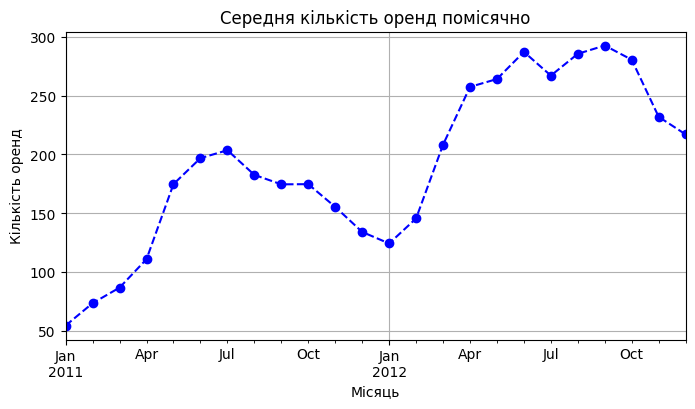

In [41]:
monthly_sales = df['count'].resample('ME').mean()
monthly_sales.plot(
    marker='o',
    color='blue',
    linestyle='--',
    figsize=(8, 4),
    title='Середня кількість оренд помісячно',
    xlabel='Місяць',
    ylabel='Кількість оренд',
    grid=True
);

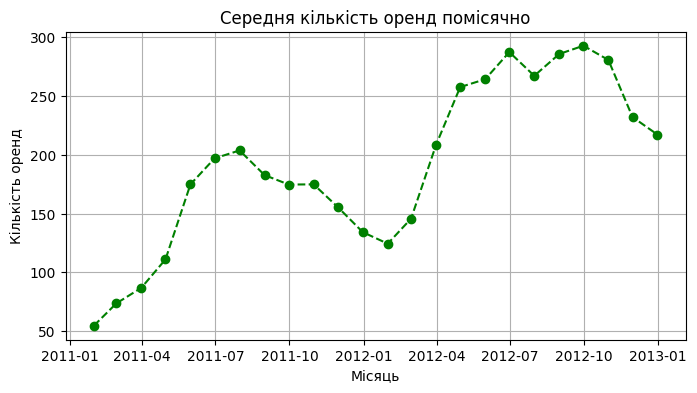

In [42]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_sales, 'o--', color='green')
plt.title('Середня кількість оренд помісячно')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.grid(True);

Головна відмінність - це вісь х, на першому графіку ми бачимо текстовий підпис місяців, на іншому він числовий. Базовий Matplotlib просто виводить дати у повному вигляді, через що підписи зливаються, якщо не зробити відступи. Pandas під капотом застосовує автоматичний DateFormatter, який групує та скорочує назви. Друга відмінність - це початок і кінець графіку. Межі графіків однакові, але Pandas автоматично додає невеличкі відступи з боків, щоб перша й остання точки не накладалися на рамку.

Візуально і більш зручніше для читання для мене саме перший графік з використанням бібліотеки Pandas.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

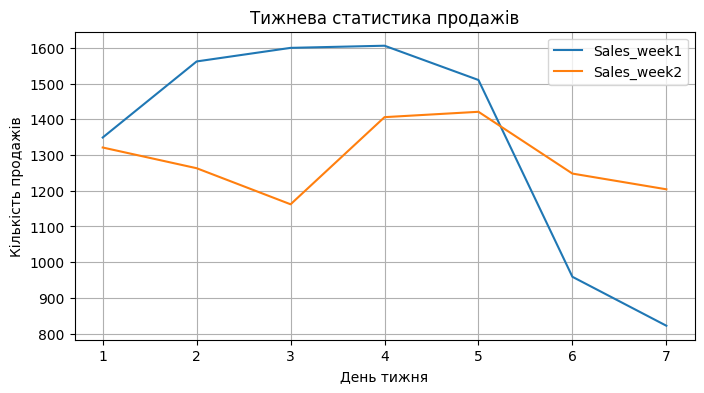

In [43]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

plt.figure(figsize=(8, 4))
plt.plot(days, sales_week1, label='Sales_week1')
plt.plot(days, sales_week2, label='Sales_week2')

plt.title('Тижнева статистика продажів')
plt.ylabel('Кількість продажів')
plt.xlabel('День тижня')
plt.grid(True)
plt.legend()
plt.show()

In [44]:
std1 = np.std(sales_week1)
std2 = np.std(sales_week2)

print(f"Стандартне відхилення W1: {std1:.2f}")
print(f"Стандартне відхилення W2: {std2:.2f}")

Стандартне відхилення W1: 300.00
Стандартне відхилення W2: 90.91


1. Продажі були стабільнішими у другий тиждень. На графіку видно, що помаранчева лінія має меншу амплітуду, тоді як синя лінія першого тижня різко падає з пятниці до неділі.
2. Стабільність найкраще оцінювати за допомогою стандартного відхилення (Standard Deviation) або дисперсії (Variance). Виконавши вище обчислення, бачимо, що стандарте відхилення в першому тижні 300, а в другому тижні 90,91. Чим менше стандартне відхилення, тим стабільніший тиждень.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

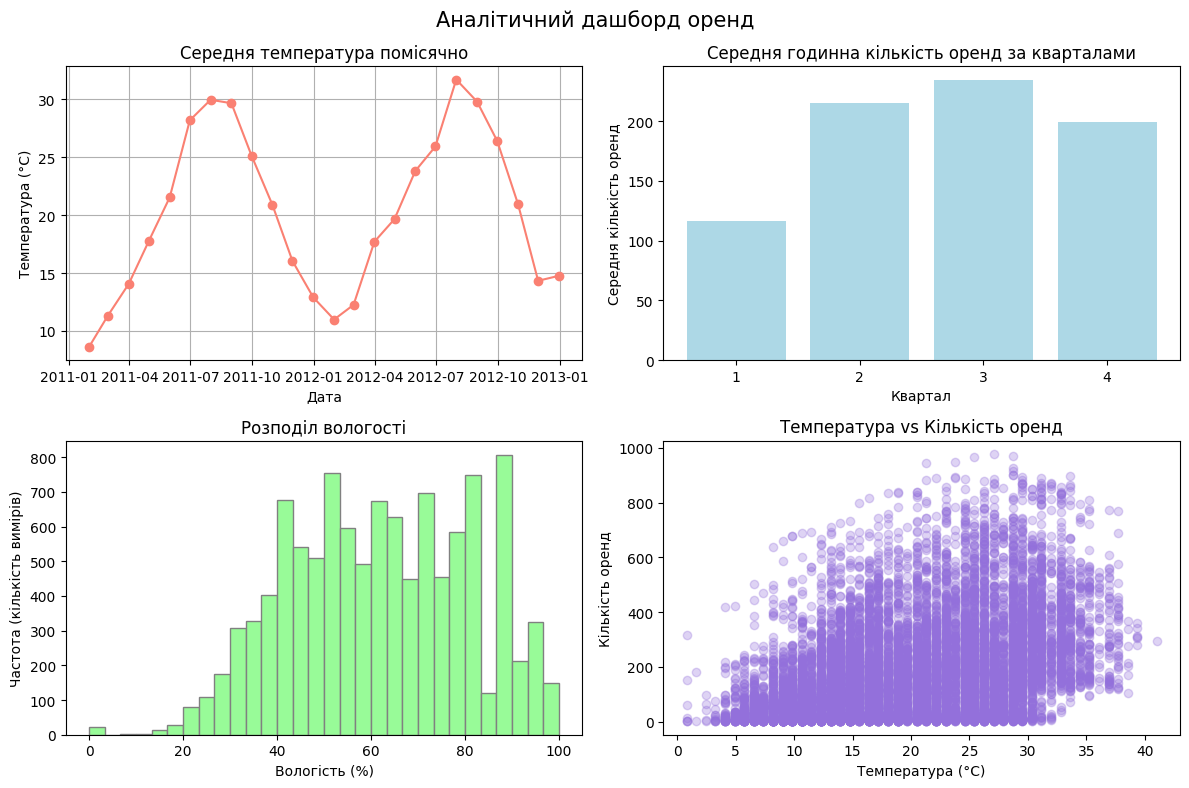

In [50]:
# Лінійний графік
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
monthly_temp = df['temp'].resample('ME').mean()
plt.plot(monthly_temp.index, monthly_temp.values, marker='o', color='salmon')
plt.title('Середня температура помісячно')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True)

# Стовпчиковий графік
plt.subplot(2, 2, 2)
df['quarter'] = df.index.quarter
quarterly_rentals = df.groupby('quarter')['count'].mean()
plt.bar(quarterly_rentals.index, quarterly_rentals.values, color='lightblue')
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.xticks([1, 2, 3, 4])

# Гістограма
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=30, color='palegreen', edgecolor='grey')
plt.title('Розподіл вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота (кількість вимірів)')

# Scatter plot
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.3, color='mediumpurple')
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')

plt.suptitle('Аналітичний дашборд оренд', fontsize=15)
plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

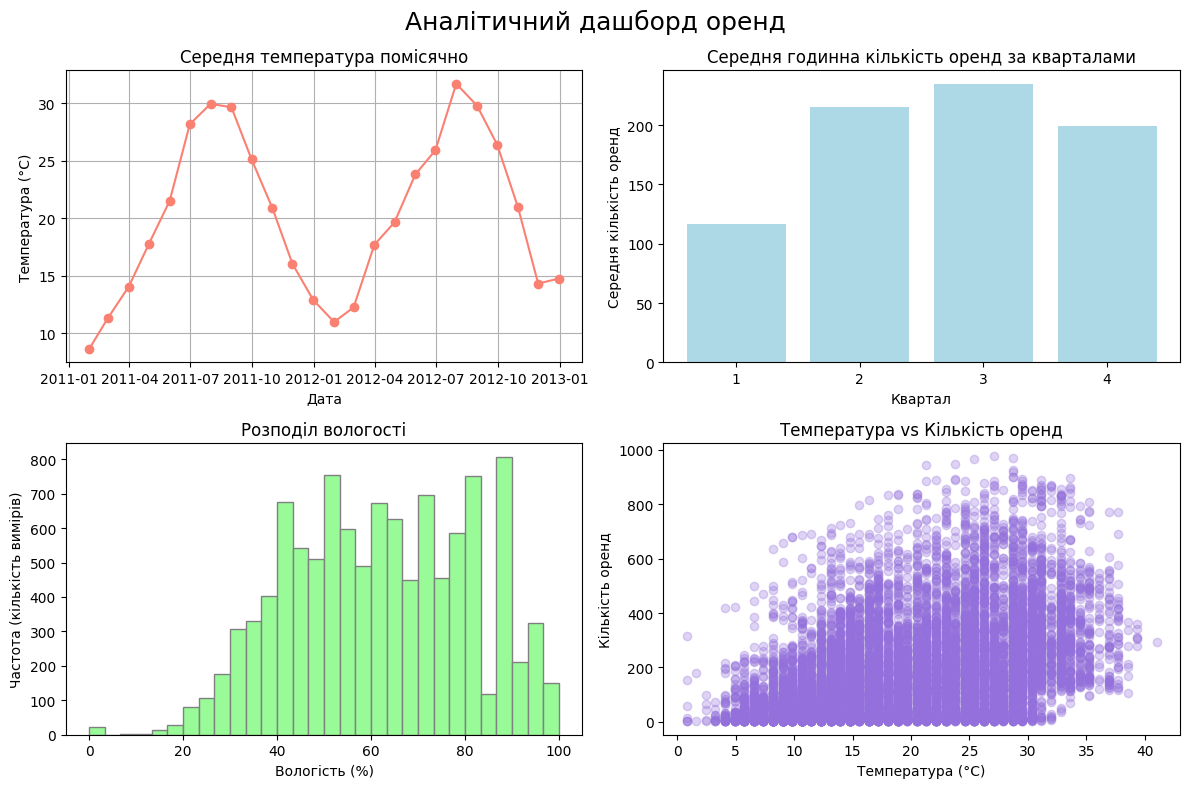

In [54]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Лінійний графік
monthly_temp = df['temp'].resample('ME').mean()
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='salmon')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Дата')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True)

# Стовпчиковий графік
df['quarter'] = df.index.quarter
quarterly_rentals = df.groupby('quarter')['count'].mean()
ax[0, 1].bar(quarterly_rentals.index, quarterly_rentals.values, color='lightblue')
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')
ax[0, 1].set_xticks([1, 2, 3, 4])

# Гістограма
ax[1, 0].hist(df['humidity'], bins=30, color='palegreen', edgecolor='grey')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота (кількість вимірів)')

 # Scatter plot
ax[1, 1].scatter(df['temp'], df['count'], alpha=0.3, color='mediumpurple')
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')


fig.suptitle('Аналітичний дашборд оренд', fontsize=18)
fig.tight_layout()
plt.show()

У plt.subplot() потрібно щоразу викликати функцію перед побудовою кожного нового графіку plt.subplot(2, 2, 1), потім plt.subplot(2, 2, 2). У plt.subplots(2, 2) вся сітка з 4 сабплотів генерується в один рядок коду.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [47]:
import matplotlib.dates as mdates

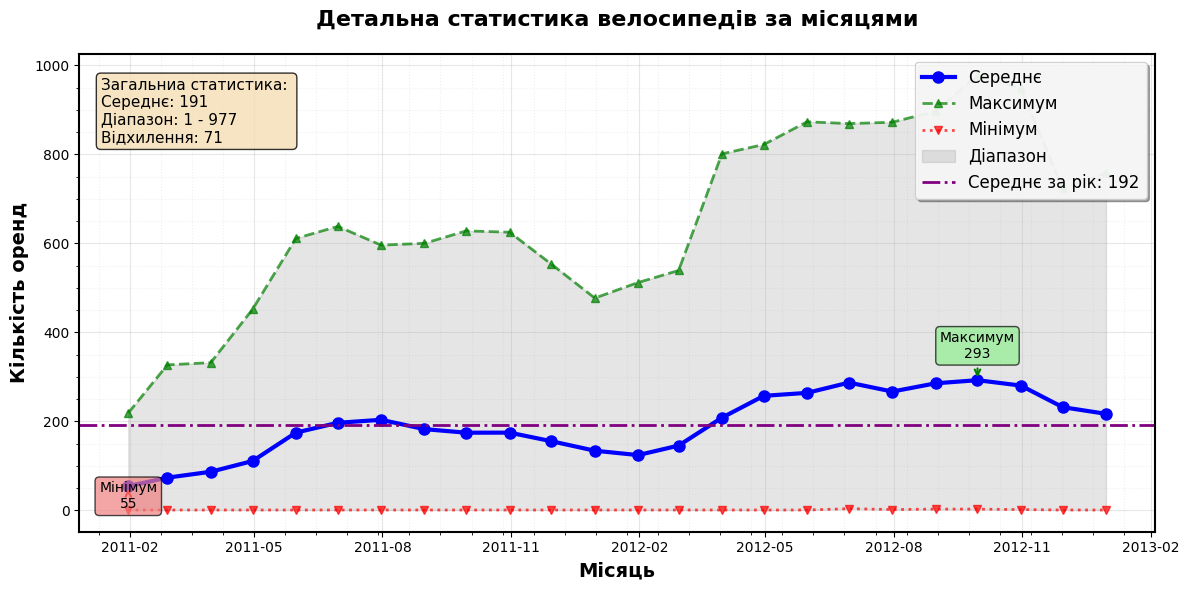

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

# Малюємо лінії з різними стилями
monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])

ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3, label='Середнє', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2, label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2, label='Мінімум', markersize=6, alpha=0.7)

# Заливка між max та min (правильний синтаксис)
ax.fill_between(month_avg.index, month_min, month_max,alpha=0.2, color='gray', label='Діапазон')

# Додаємо анотації для екстремальних значень min та max
ax.annotate(f'Максимум\n{monthly_stats["mean"].max():.0f}',
            xy=(monthly_stats["mean"].idxmax(), monthly_stats["mean"].max()),
            xytext=(monthly_stats["mean"].idxmax(), monthly_stats["mean"].max() + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))
ax.annotate(f'Мінімум\n{monthly_stats["mean"].min():.0f}',
            xy=(monthly_stats["mean"].idxmin(), monthly_stats["mean"].min()),
            xytext=(monthly_stats["mean"].idxmin(), monthly_stats["mean"].min() - 50),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))

# Налаштування осей
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика велосипедів за місяцями',
             fontsize=16, fontweight='bold', pad=20)

# Форматування дат на осі X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Додаємо середню лінію за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Покращуємо легенду
ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Додаємо текст з додатковою статистикою
textstr = f'Загальниа статистика: \n'
textstr += f'Середнє: {monthly_stats["mean"].mean():.0f}\n'
textstr += f'Діапазон: {monthly_stats["min"].min():.0f} - {monthly_stats["max"].max():.0f}\n'
textstr += f'Відхилення: {monthly_stats["mean"].std():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()